# Geometria computacional
# Busqueda de Rutas en Ambientes Poligonales

### Miguel Angel Peñaloza

1. Implementar un algoritmo para generar obst ́aculos poligonales simples
dentro de un rect ́angulo. Pueden consultar, https://ruevko.github.io/
hexagonal/post/2020/11/11-ejercicio-benchmark-generador-poligonos/.
El objetivo es que su programa pueda generar ambientes poligonales aleatorios
con un total n de aristas.
2. Implementar el algoritmo descrito en clase para generar la descomposici ́on
trapezoidal de un ambiente poligonal dado y la estructura de b ́usqueda
correspondiente.
3. Construir el grafo de adyacencia a partir de las celdas generadas en la
descomposici ́on trapezoidal. Considerar como nodos del grafo los centroides
de los trapezoides y el punto medio de las paredes verticales de cada
trapezoide. Implementar un algoritmo para encontrar una ruta entre dos
celdas, seleccionadas aleatoriamente, a partir del grafo de adyacencia.
4. Evaluar num ́ericamente el tiempo de construcci ́on de la descomposici ́on
y la estructura de b ́usqueda subyacente, adem ́as de la construcci ́on del
grafo de adyacencia, como funci ́on del n ́umero de aristas en el ambiente.
Caracterizar num ́ericamente el tiempo de b ́usqueda de las trayectorias
entre celdas aleatorias como funci ́on del n ́umero de aristas en el ambiente.
Comparar sus resultados con los discutidos en clase.

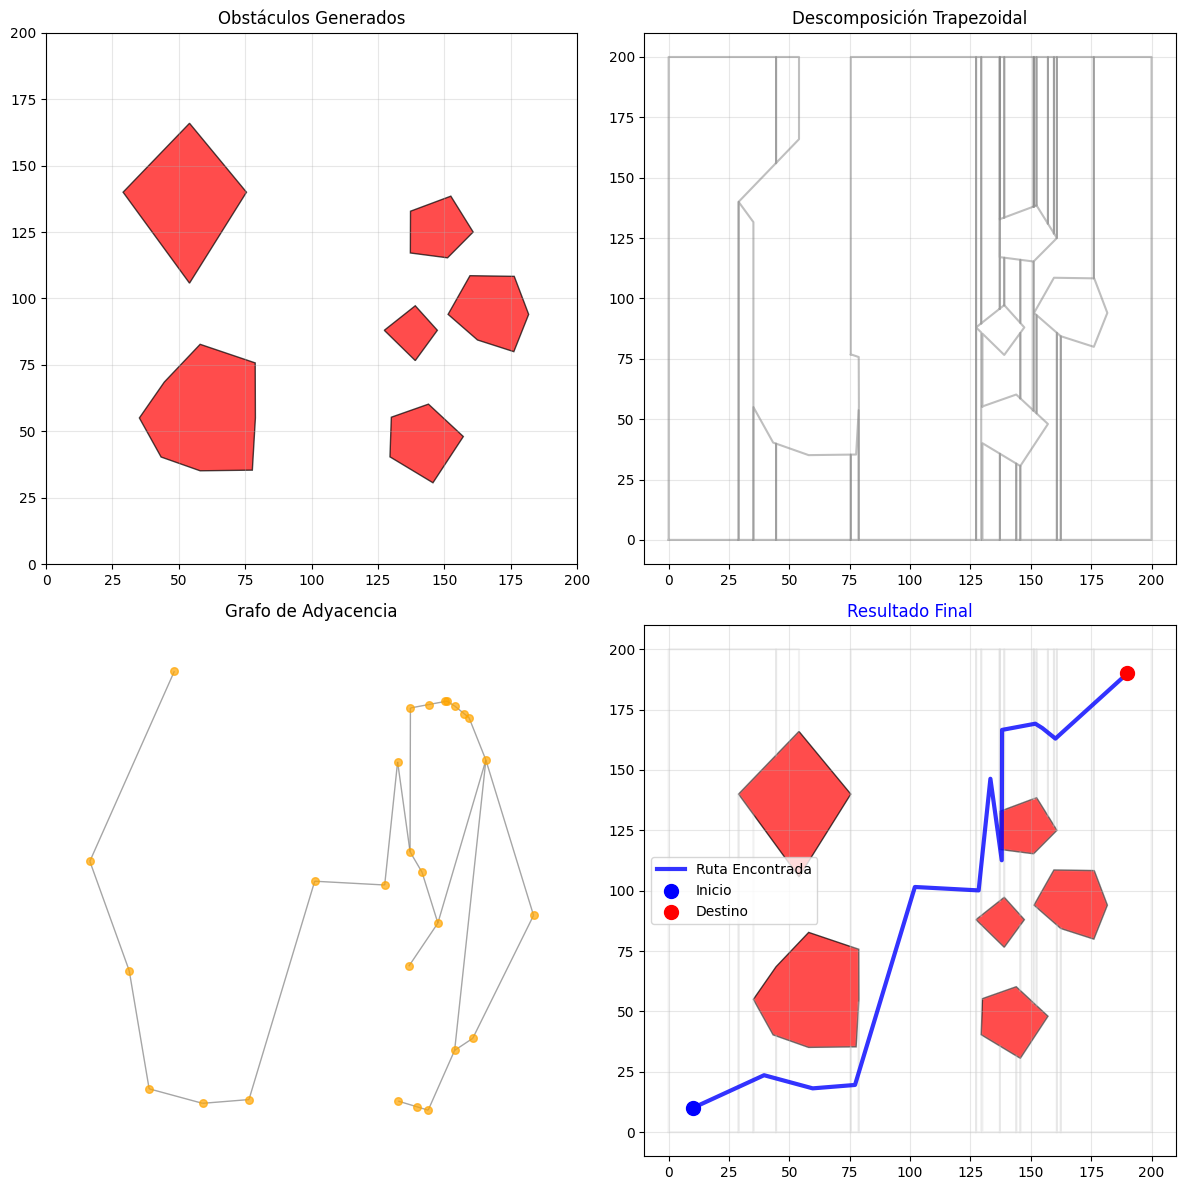


REPORTE DE PLANIFICACIÓN DE RUTA
Obstáculos generados: 6
Trapezoides válidos: 27
Nodos en grafo: 27
Aristas en grafo: 28
Tiempo Dijkstra: 0.002857 segundos
Nodos en ruta: 14
Longitud ruta: 309.50 unidades
Seguridad: INSEGURA
Violaciones encontradas: 4
Distancia mínima a obstáculos: 0.00

INICIANDO EVAL
Eval
Configuraciones: [2, 4, 6, 8, 10, 12, 15]
Trials por configuracion: 8

INICIANDO EVALUACIÓN DE RENDIMIENTO

Evaluando configuración: 2 obstáculos
  Promedio aristas: 9.4
  Promedio nodos: 8.8
  Descomposición: 14.97 ms
  Construcción grafo: 10.52 ms
  Búsqueda promedio: 0.4346 ms
Completados 8/8 trials

Evaluando configuración: 4 obstáculos
  Promedio aristas: 18.4
  Promedio nodos: 17.1
  Descomposición: 50.96 ms
  Construcción grafo: 28.68 ms
  Búsqueda promedio: 0.9266 ms
Completados 8/8 trials

Evaluando configuración: 6 obstáculos
  Promedio aristas: 30.2
  Promedio nodos: 28.6
  Descomposición: 50.38 ms
  Construcción grafo: 39.14 ms
  Búsqueda promedio: 0.1791 ms
Completados

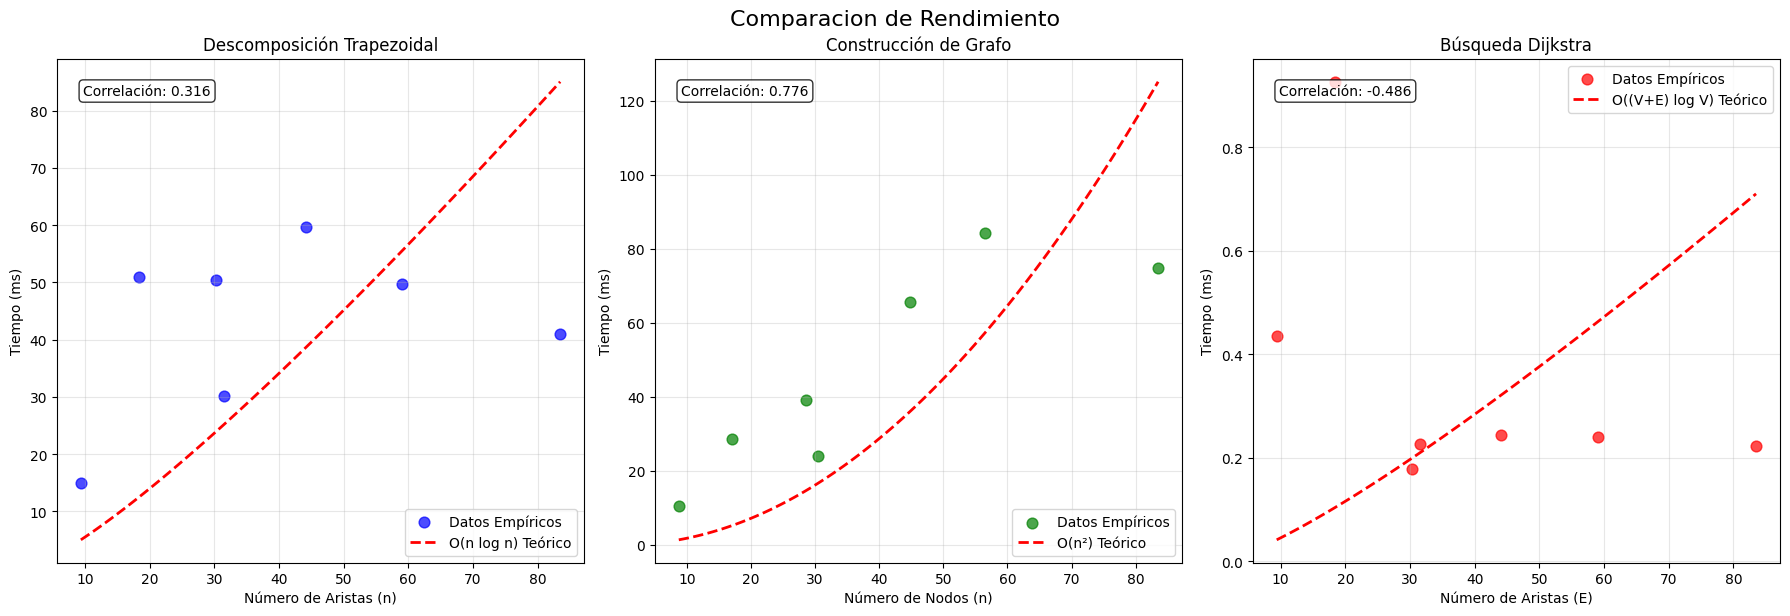


ANÁLISIS DE COMPLEJIDAD TEMPORAL
Descomposicion Trapezoidal con O(n log n): POBRE (r=0.316)
Construccion de Grafo con O(n²): BUENA (r=0.776)
Busqueda Dijkstra con O((V+E) log V): POBRE (r=-0.486)

ESTADÍSTICAS GENERALES:
Configuraciones evaluadas: 7
Rango de aristas: 9 - 84
Rango de nodos: 9 - 84

TIEMPOS PROMEDIO:
Descomposición: 42.40 ms
Construcción grafo: 46.70 ms
Búsqueda: 0.3536 ms
Total promedio: 89.46 ms


In [ ]:

try:
    import scipy
except ImportError:
    !pip install scipy

!pip install shapely networkx matplotlib scipy

# Imports
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, Point
from shapely.geometry import MultiLineString
from shapely.ops import polygonize, unary_union
from shapely.affinity import translate
import networkx as nx
import math
import random
import numpy as np
import time
from typing import List, Tuple, Optional, Dict, Set
import logging
import statistics
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar log
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Semila
random.seed(42)
np.random.seed(42)

class PathPlanningConfig:
    def __init__(self):
        self.workspace_size = 200
        self.max_obstacles = 6
        self.max_obstacle_size = 30
        self.min_obstacle_size = 10
        self.min_obstacle_separation = 5.0
        self.min_trapezoid_area = 10.0
        self.max_construction_attempts = 100
        self.adjacency_tolerance = 1e-6
        self.min_edge_length = 1e-6
        self.connection_safety_margin = 2.0

config = PathPlanningConfig()

# espacio de trnabajo
def create_workspace(size: int) -> Polygon:
    """Crear espacio de trabajo"""
    coords = [(0, 0), (size, 0), (size, size), (0, size)]
    workspace = Polygon(coords)

    if not workspace.is_valid:
        logger.error("Workspace inalido creado")
        raise ValueError("No se pudo crear un workspace ")

    logger.info(f"Workspace creado: {size}x{size}")
    return workspace

def generate_robust_obstacle(max_size: int, min_size: int, workspace_bounds: Tuple[int, int, int, int]) -> Optional[Polygon]:
    """Generar obstaculo"""
    x_min, y_min, x_max, y_max = workspace_bounds


    if x_max - x_min < max_size * 2 or y_max - y_min < max_size * 2:
        logger.warning("Workspace demasiado pequeño para obstaculos")
        return None

    try:
        size = random.randint(min_size, max_size)
        sides = random.randint(4, 8)
        angle_step = 2 * math.pi / sides

        # Generar poligono
        coords = []
        for i in range(sides):
            radius_variation = random.uniform(0.7, 1.3) * size
            x = math.cos(i * angle_step) * radius_variation
            y = math.sin(i * angle_step) * radius_variation
            coords.append((x, y))


        margin = max_size + config.connection_safety_margin
        tx = random.randint(x_min + margin, x_max - margin)
        ty = random.randint(y_min + margin, y_max - margin)

        poly = Polygon(coords)
        if not poly.is_valid:
            poly = poly.buffer(0)

        obstacle = translate(poly, tx, ty)

        if not obstacle.is_valid or obstacle.area < config.min_trapezoid_area:
            return None

        return obstacle

    except Exception as e:
        logger.warning(f"Error generando obstaco: {e}")
        return None

def generate_obstacles_with_validation(workspace: Polygon, max_obstacles: int) -> List[Polygon]:
    """Generar obstaculos"""
    obstacles = []
    attempts = 0
    bounds = workspace.bounds

    while len(obstacles) < max_obstacles and attempts < config.max_construction_attempts:
        new_obs = generate_robust_obstacle(
            config.max_obstacle_size,
            config.min_obstacle_size,
            bounds
        )

        if new_obs is None:
            attempts += 1
            continue

        # contenicion del espacio de trabajo
        if not workspace.contains(new_obs):
            attempts += 1
            continue


        valid_separation = True
        for existing_obs in obstacles:
            distance = new_obs.distance(existing_obs)
            if distance < config.min_obstacle_separation:
                valid_separation = False
                break

        if valid_separation:
            obstacles.append(new_obs)
            logger.info(f"Obstaculo {len(obstacles)} ")

        attempts += 1

    logger.info(f"Generados {len(obstacles)} obstaculos en {attempts} intentos")
    return obstacles

# 2. DESCOMPOSICIÓN TRAPEZOIDAL
def robust_trapezoidal_decomposition(workspace: Polygon, obstacles: List[Polygon]) -> Tuple[List[Polygon], Polygon]:
    """Descomposin trapezoidal """
    try:
        # Crear holes de obstáculos
        obstacles_coords = []
        for i, obs in enumerate(obstacles):
            coords = list(obs.exterior.coords)[:-1]  #
            if len(coords) >= 3:  # Validar m
                obstacles_coords.append(coords)
            else:
                logger.warning(f"Obstculo {i} pocos vertices")

        # Crear espacio libre
        workspace_coords = list(workspace.exterior.coords)[:-1]
        free_space = Polygon(workspace_coords, holes=obstacles_coords)

        if not free_space.is_valid:
            free_space = free_space.buffer(0)
            logger.warning("Espacio libre reparado")

        # Obtener coordenadas X
        x_coords = set()
        for x, y in workspace_coords:
            x_coords.add(round(x, 6))

        for obs_coords in obstacles_coords:
            for x, y in obs_coords:
                x_coords.add(round(x, 6))

        xs = sorted(x_coords)
        ymin, ymax = workspace.bounds[1], workspace.bounds[3]

        # Crear lineas
        lines = []
        for x in xs:
            vert_line = LineString([(x, ymin - 1), (x, ymax + 1)])

            try:
                inter = free_space.intersection(vert_line)
                if inter.is_empty:
                    continue

                if inter.geom_type == 'LineString':
                    if inter.length > config.min_edge_length:
                        lines.append(inter)
                elif inter.geom_type == 'MultiLineString':
                    for seg in inter.geoms:
                        if isinstance(seg, LineString) and seg.length > config.min_edge_length:
                            lines.append(seg)
            except Exception as e:
                logger.warning(f"Error procesando linea vertical en x={x}: {e}")
                continue


        boundary = free_space.boundary
        if boundary.geom_type == 'LineString':
            lines.append(boundary)
        elif boundary.geom_type == 'MultiLineString':
            for seg in boundary.geoms:
                if isinstance(seg, LineString):
                    lines.append(seg)

        # Crear trapezoides
        if not lines:
            logger.error("No se pudieron crear lineas para la descomposicn")
            return [], free_space

        try:
            unified_lines = unary_union(lines)
            trapezoids = list(polygonize(unified_lines))
        except Exception as e:
            logger.error(f"Error en polygonize: {e}")
            return [], free_space

        # Filtrar trapezoides permitidos
        valid_trapezoids = []
        for trap in trapezoids:
            if (trap.is_valid and
                trap.area > config.min_trapezoid_area and
                free_space.contains(trap.centroid)):
                valid_trapezoids.append(trap)

        logger.info(f"Descomposición completada: {len(valid_trapezoids)} trapezoides validos")
        return valid_trapezoids, free_space

    except Exception as e:
        logger.error(f"Error en descomposición trapezoidal: {e}")
        return [], workspace

# 3. comstruccion del grafo
class RobustGraphBuilder:
    def __init__(self, config: PathPlanningConfig):
        self.config = config

    def build_adjacency_graph(self, trapezoids: List[Polygon], free_space: Polygon) -> Tuple[nx.Graph, List[Tuple[float, float]], Dict[int, int]]:
        """Construir grafo de adyacencia con validacion"""
        if not trapezoids:
            logger.error("No hay trapezoides para construir el grafo")
            return nx.Graph(), [], {}

        # Validar centroides y crear mapeo
        valid_nodes = []
        valid_centroids = []
        node_to_trapezoid = {}

        for i, trap in enumerate(trapezoids):
            try:
                centroid = trap.centroid
                if (centroid.is_valid and
                    free_space.contains(centroid) and
                    not math.isnan(centroid.x) and
                    not math.isnan(centroid.y)):

                    node_id = len(valid_nodes)
                    valid_nodes.append(node_id)
                    valid_centroids.append((centroid.x, centroid.y))
                    node_to_trapezoid[node_id] = i

            except Exception as e:
                logger.warning(f"Error procesando trapezoide {i}: {e}")
                continue

        if len(valid_nodes) < 2:
            logger.error("Insuficientes nodos validos para construir grafo")
            return nx.Graph(), valid_centroids, node_to_trapezoid

        # Crear grafo
        G = nx.Graph()
        for node_id, centroid in zip(valid_nodes, valid_centroids):
            G.add_node(node_id, pos=centroid)

        # Construir adyacencias con validacion robusta
        edges_added = 0
        total_checks = 0

        for i in range(len(valid_nodes)):
            for j in range(i + 1, len(valid_nodes)):
                total_checks += 1

                try:
                    node_i, node_j = valid_nodes[i], valid_nodes[j]
                    trap_i = trapezoids[node_to_trapezoid[node_i]]
                    trap_j = trapezoids[node_to_trapezoid[node_j]]

                    # Verificar adyacencia geotrica
                    if self._are_adjacent(trap_i, trap_j, free_space):
                        distance = self._calculate_safe_distance(valid_centroids[i], valid_centroids[j])
                        G.add_edge(node_i, node_j, weight=distance)
                        edges_added += 1

                except Exception as e:
                    logger.warning(f"Error verificando adyacencia entre nodos {valid_nodes[i]}-{valid_nodes[j]}: {e}")
                    continue

        logger.info(f"Grafo construido: {len(valid_nodes)} nodos, {edges_added} aristas de {total_checks} verificaciones")

        return G, valid_centroids, node_to_trapezoid

    def _are_adjacent(self, trap1: Polygon, trap2: Polygon, free_space: Polygon) -> bool:
        """Verificar si dos trapezoides son adyacentes de forma robusta."""
        try:
            intersection = trap1.intersection(trap2)

            if intersection.is_empty:
                return False

            # Verificar diferentes tipos de interseccion
            if intersection.geom_type == 'LineString':
                return intersection.length > self.config.adjacency_tolerance
            elif intersection.geom_type == 'MultiLineString':
                total_length = sum(seg.length for seg in intersection.geoms
                                 if isinstance(seg, LineString))
                return total_length > self.config.adjacency_tolerance
            elif intersection.geom_type == 'Point':
                return False  # Solo un punto no es suficiente para adyacencia
            else:

                return hasattr(intersection, 'area') and intersection.area < self.config.adjacency_tolerance

        except Exception as e:
            logger.warning(f"Error verificando adyacencia: {e}")
            return False

    def _calculate_safe_distance(self, p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
        """Calcular distancia euclidiana con validac."""
        try:
            dx = p2[0] - p1[0]
            dy = p2[1] - p1[1]
            distance = math.sqrt(dx*dx + dy*dy)

            if math.isnan(distance) or math.isinf(distance):
                logger.warning("Distancia invalida calculada, usando valor por defecto")
                return 1000.0

            return max(distance, self.config.min_edge_length)  # Evitar distancias cero

        except Exception:
            logger.warning("Error calculando distancia, usando valor por defecto")
            return 1000.0

# 4. DJKSTRA
class RobustPathFinder:
    def __init__(self, config: PathPlanningConfig):
        self.config = config

    def find_nearest_node(self, point: Tuple[float, float], centroids: List[Tuple[float, float]]) -> Optional[int]:
        """Encontrar nodo mas cercano con validacin."""
        if not centroids:
            return None

        try:
            min_dist = float('inf')
            nearest_idx = None

            for i, (cx, cy) in enumerate(centroids):
                if math.isnan(cx) or math.isnan(cy):
                    continue

                dist = math.sqrt((point[0] - cx)**2 + (point[1] - cy)**2)

                if not (math.isnan(dist) or math.isinf(dist)) and dist < min_dist:
                    min_dist = dist
                    nearest_idx = i

            return nearest_idx

        except Exception as e:
            logger.error(f"Error encontrando nodo mas cercano: {e}")
            return None

    def find_path_dijkstra(self, graph: nx.Graph, start_node: int, goal_node: int) -> Tuple[Optional[List[int]], float, Dict]:
        """Ejecutar Dijkstra con manejo robusto de errores y mricas."""
        if not graph.has_node(start_node) or not graph.has_node(goal_node):
            logger.error("Nodos de inicio o destino no existen en el grafo")
            return None, 0.0, {"error": "Nodos invaidos"}

        if start_node == goal_node:
            logger.info("Nodo de inicio y destino son el mismo")
            return [start_node], 0.0, {"same_node": True}

        start_time = time.time()
        metrics = {"nodes_explored": 0, "edges_explored": 0}

        try:

            if not nx.has_path(graph, start_node, goal_node):
                logger.error("No existe camino entre los nodos")
                return None, time.time() - start_time, {"error": "No hay camino"}

            # Ejecutar Dijkstra
            for u, v, data in graph.edges(data=True):
                weight = data.get('weight', 1.0)
                if math.isnan(weight) or math.isinf(weight) or weight <= 0:
                    logger.warning(f"Peso inválido en arista {u}-{v}: {weight}")
                    graph[u][v]['weight'] = 1.0  # Peso por defecto

            path = nx.dijkstra_path(graph, start_node, goal_node, weight='weight')
            path_length = nx.dijkstra_path_length(graph, start_node, goal_node, weight='weight')

            computation_time = time.time() - start_time

            metrics.update({
                "path_length": path_length,
                "path_nodes": len(path),
                "success": True
            })

            logger.info(f"Camino encontrado: {len(path)} nodos, longitud {path_length:.2f}")
            return path, computation_time, metrics

        except nx.NetworkXNoPath:
            logger.error("Dijkstra no encont camino")
            return None, time.time() - start_time, {"error": "No path found"}
        except Exception as e:
            logger.error(f"Error en Dijkstra: {e}")
            return None, time.time() - start_time, {"error": str(e)}

def validate_path_safety(path_coords: List[Tuple[float, float]], obstacles: List[Polygon],
                        safety_margin: float = 1.0) -> Dict[str, any]:
    """Validar que la ruta no intersecte obstáculos con margen de seguridad."""
    validation_result = {
        "is_safe": True,
        "intersections": [],
        "min_clearance": float('inf'),
        "total_segments": len(path_coords) - 1
    }

    if len(path_coords) < 2:
        validation_result["is_safe"] = False
        validation_result["error"] = "Ruta muy corta"
        return validation_result

    for i in range(len(path_coords) - 1):
        try:
            segment = LineString([path_coords[i], path_coords[i+1]])

            for j, obstacle in enumerate(obstacles):
                # Verificar intersección directa
                if segment.intersects(obstacle):
                    validation_result["is_safe"] = False
                    validation_result["intersections"].append({
                        "segment": i,
                        "obstacle": j,
                        "type": "direct_intersection"
                    })

                # Verificar margen de seguridad
                distance = segment.distance(obstacle)
                if distance < safety_margin:
                    validation_result["is_safe"] = False
                    validation_result["intersections"].append({
                        "segment": i,
                        "obstacle": j,
                        "type": "safety_margin_violation",
                        "distance": distance
                    })

                validation_result["min_clearance"] = min(validation_result["min_clearance"], distance)

        except Exception as e:
            logger.warning(f"Error validando segmento {i}: {e}")
            validation_result["is_safe"] = False

    return validation_result

#  PRINCIPAL
def main():
    logger.info("Iniciando planificacion de ruta robusta...")

    try:
        # 1. Crear workspace y obstaculos
        workspace = create_workspace(config.workspace_size)
        obstacles = generate_obstacles_with_validation(workspace, config.max_obstacles)

        if not obstacles:
            logger.error("No se pudieron generar obstaculos")
            return

        # 2. Descomposician trapezoidal
        trapezoids, free_space = robust_trapezoidal_decomposition(workspace, obstacles)

        if not trapezoids:
            logger.error("Fallo la descomposicion trapezoidal")
            return

        # 3. Construccion del grafo
        graph_builder = RobustGraphBuilder(config)
        graph, centroids, node_mapping = graph_builder.build_adjacency_graph(trapezoids, free_space)

        if graph.number_of_nodes() < 2:
            logger.error("Grafo insuficiente para planificacion")
            return

        # 4. Encontrar ruta
        path_finder = RobustPathFinder(config)
        start_point = (10, 10)
        goal_point = (190, 190)

        start_node = path_finder.find_nearest_node(start_point, centroids)
        goal_node = path_finder.find_nearest_node(goal_point, centroids)

        if start_node is None or goal_node is None:
            logger.error("No se pudieron encontrar nodos de inicio o destino")
            return

        path, computation_time, metrics = path_finder.find_path_dijkstra(graph, start_node, goal_node)

        # 5. Validar seguridad de la ruta
        validation_result = {"is_safe": False}
        if path:
            path_coords = [start_point] + [centroids[n] for n in path] + [goal_point]
            validation_result = validate_path_safety(path_coords, obstacles, config.connection_safety_margin)


        fig, axes = plt.subplots(2, 2, figsize=(12, 12))

        # Obstáculos
        ax1 = axes[0, 0]
        for obstacle in obstacles:
            x, y = obstacle.exterior.xy
            ax1.fill(x, y, alpha=0.7, color='red', edgecolor='black')
        ax1.set_xlim(0, config.workspace_size)
        ax1.set_ylim(0, config.workspace_size)
        ax1.set_title('Obstáculos Generados')
        ax1.set_aspect('equal')
        ax1.grid(True, alpha=0.3)

        # Descomposición trapezoidal
        ax2 = axes[0, 1]
        for trap in trapezoids:
            x, y = trap.exterior.xy
            ax2.plot(x, y, 'gray', alpha=0.5)
        ax2.set_title('Descomposición Trapezoidal')
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)

        # Grafo
        ax3 = axes[1, 0]
        pos = {i: centroids[i] for i in range(len(centroids))}
        nx.draw(graph, pos, ax=ax3, node_size=30, node_color='orange',
                edge_color='gray', alpha=0.7)
        ax3.set_title('Grafo de Adyacencia')
        ax3.grid(True, alpha=0.3)

        #  Ruta final
        ax4 = axes[1, 1]

        # onstaculos
        for obstacle in obstacles:
            x, y = obstacle.exterior.xy
            ax4.fill(x, y, alpha=0.7, color='red', edgecolor='black')

        # trapezoides
        for trap in trapezoids:
            x, y = trap.exterior.xy
            ax4.plot(x, y, 'lightgray', alpha=0.3)

        #  ruta
        if path and validation_result.get("is_safe", False):
            path_coords = [start_point] + [centroids[n] for n in path] + [goal_point]
            x_path = [p[0] for p in path_coords]
            y_path = [p[1] for p in path_coords]
            ax4.plot(x_path, y_path, '-g', linewidth=3, label='Ruta Encontrada', alpha=0.8)
            status_color = 'green'
        elif path:
            path_coords = [start_point] + [centroids[n] for n in path] + [goal_point]
            x_path = [p[0] for p in path_coords]
            y_path = [p[1] for p in path_coords]
            ax4.plot(x_path, y_path, '-b', linewidth=3, label='Ruta Encontrada', alpha=0.8)
            status_color = 'blue'
        else:
            status_color = 'gray'

        ax4.scatter(*start_point, c='blue', s=100, label='Inicio', zorder=5)
        ax4.scatter(*goal_point, c='red', s=100, label='Destino', zorder=5)
        ax4.set_title('Resultado Final', color=status_color)
        ax4.legend()
        ax4.set_aspect('equal')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # reporte
        print("\n" + "="*60)
        print("REPORTE DE PLANIFICACIÓN DE RUTA")
        print("="*60)
        print(f"Obstáculos generados: {len(obstacles)}")
        print(f"Trapezoides válidos: {len(trapezoids)}")
        print(f"Nodos en grafo: {graph.number_of_nodes()}")
        print(f"Aristas en grafo: {graph.number_of_edges()}")
        print(f"Tiempo Dijkstra: {computation_time:.6f} segundos")

        if path:
            print(f"Nodos en ruta: {len(path)}")
            print(f"Longitud ruta: {metrics.get('path_length', 0):.2f} unidades")

            safety_status = "SEGURA" if validation_result.get("is_safe", False) else "INSEGURA"
            print(f"Seguridad: {safety_status}")

            if not validation_result.get("is_safe", False):
                intersections = len(validation_result.get("intersections", []))
                print(f"Violaciones encontradas: {intersections}")

            min_clearance = validation_result.get("min_clearance", float('inf'))
            if min_clearance != float('inf'):
                print(f"Distancia mínima a obstáculos: {min_clearance:.2f}")
        else:
            print("No se encontró ruta")
            print(f"Error: {metrics.get('error', 'Desconocido')}")

        print("="*60)

    except Exception as e:
        logger.error(f"Error en ejecución principal: {e}")
        raise

#rendimiiento
class PerformanceEvaluator:
    def __init__(self):
        self.results = {
            'decomposition_times': [],
            'graph_construction_times': [],
            'search_times': [],
            'num_edges': [],
            'num_nodes': [],
            'num_obstacles': [],
            'environment_complexity': []
        }

    def evaluate_performance_vs_complexity(self, obstacle_counts: List[int], trials_per_config: int = 10):
        """Evaluar rendimiento como función del número de obstáculos/aristas."""
        print("\nINICIANDO EVALUACIÓN DE RENDIMIENTO")
        print("="*60)

        for obstacle_count in obstacle_counts:
            print(f"\nEvaluando configuración: {obstacle_count} obstáculos")
            config_results = {
                'decomp_times': [],
                'graph_times': [],
                'search_times': [],
                'edges': [],
                'nodes': [],
                'success_rate': 0
            }

            successful_trials = 0

            for trial in range(trials_per_config):
                try:
                    # Generar ambiente
                    workspace = create_workspace(config.workspace_size)
                    temp_config = PathPlanningConfig()
                    temp_config.max_obstacles = obstacle_count
                    obstacles = self._generate_obstacles_for_trial(workspace, obstacle_count)

                    if len(obstacles) < obstacle_count * 0.7:  # Al menos 70% de obstáculos solicitados
                        continue

                    #descomposicion trapezoidal
                    decomp_start = time.perf_counter()
                    trapezoids, free_space = robust_trapezoidal_decomposition(workspace, obstacles)
                    decomp_time = time.perf_counter() - decomp_start

                    if not trapezoids:
                        continue

                    # construccion del grafo
                    graph_start = time.perf_counter()
                    graph_builder = RobustGraphBuilder(temp_config)
                    graph, centroids, _ = graph_builder.build_adjacency_graph(trapezoids, free_space)
                    graph_time = time.perf_counter() - graph_start

                    if graph.number_of_nodes() < 2:
                        continue


                    search_times = []
                    path_finder = RobustPathFinder(temp_config)

                    #
                    search_count = min(10, len(centroids) // 2)  # Más búsquedas
                    for _ in range(search_count):
                        start_idx = random.randint(0, len(centroids) - 1)
                        goal_idx = random.randint(0, len(centroids) - 1)

                        if start_idx != goal_idx and nx.has_path(graph, start_idx, goal_idx):
                            search_start = time.perf_counter()
                            path, _, _ = path_finder.find_path_dijkstra(graph, start_idx, goal_idx)
                            search_time = time.perf_counter() - search_start
                            if path:  # Solo contar búsquedas exitosas
                                search_times.append(search_time)

                    # Resultados
                    config_results['decomp_times'].append(decomp_time)
                    config_results['graph_times'].append(graph_time)
                    config_results['search_times'].extend(search_times)
                    config_results['edges'].append(graph.number_of_edges())
                    config_results['nodes'].append(graph.number_of_nodes())

                    successful_trials += 1

                except Exception as e:
                    logger.warning(f"Error en trial {trial}: {e}")
                    continue

            if successful_trials > 0:
                config_results['success_rate'] = successful_trials / trials_per_config
                self._record_configuration_results(obstacle_count, config_results)
                print(f"Completados {successful_trials}/{trials_per_config} trials")
            else:
                print(f"No se completaron trials para {obstacle_count} obstáculos")

    def _generate_obstacles_for_trial(self, workspace: Polygon, target_count: int) -> List[Polygon]:
        """Generar obstáculos para un trial específico."""
        obstacles = []
        max_attempts = target_count * 20
        attempts = 0
        bounds = workspace.bounds

        while len(obstacles) < target_count and attempts < max_attempts:
            size = random.randint(8, 25)  # Tamaños más controlados
            sides = random.randint(4, 6)
            angle_step = 2 * math.pi / sides

            coords = []
            for i in range(sides):
                radius = size * random.uniform(0.8, 1.2)
                x = math.cos(i * angle_step) * radius
                y = math.sin(i * angle_step) * radius
                coords.append((x, y))

            margin = 30
            tx = random.randint(int(bounds[0]) + margin, int(bounds[2]) - margin)
            ty = random.randint(int(bounds[1]) + margin, int(bounds[3]) - margin)

            try:
                poly = Polygon(coords)
                if not poly.is_valid:
                    poly = poly.buffer(0)

                obstacle = translate(poly, tx, ty)

                if (workspace.contains(obstacle) and
                    all(obstacle.distance(existing) > 3.0 for existing in obstacles)):
                    obstacles.append(obstacle)
            except:
                pass

            attempts += 1

        return obstacles

    def _record_configuration_results(self, obstacle_count: int, config_results: dict):
        """Registrar resultados de una configuración."""
        avg_decomp = np.mean(config_results['decomp_times'])
        avg_graph = np.mean(config_results['graph_times'])
        avg_search = np.mean(config_results['search_times'])
        avg_edges = np.mean(config_results['edges'])
        avg_nodes = np.mean(config_results['nodes'])

        self.results['decomposition_times'].append(avg_decomp)
        self.results['graph_construction_times'].append(avg_graph)
        self.results['search_times'].append(avg_search)
        self.results['num_edges'].append(avg_edges)
        self.results['num_nodes'].append(avg_nodes)
        self.results['num_obstacles'].append(obstacle_count)
        self.results['environment_complexity'].append(avg_edges + avg_nodes)

        # Mostrar estadísticas inmediatas
        print(f"  Promedio aristas: {avg_edges:.1f}")
        print(f"  Promedio nodos: {avg_nodes:.1f}")
        print(f"  Descomposición: {avg_decomp*1000:.2f} ms")
        print(f"  Construcción grafo: {avg_graph*1000:.2f} ms")
        print(f"  Búsqueda promedio: {avg_search*1000:.4f} ms")

    def plot_performance_comparison(self):
        """Crear gráfico único comparando rendimiento empírico con teórico."""
        if len(self.results['num_edges']) < 3:
            print("Datos insuficientes para generar gráfico")
            return

        # Preparar datos
        edges = np.array(self.results['num_edges'])
        nodes = np.array(self.results['num_nodes'])
        decomp_times = np.array(self.results['decomposition_times']) * 1000  # a milisegundos
        graph_times = np.array(self.results['graph_construction_times']) * 1000
        search_times = np.array(self.results['search_times']) * 1000

        # Crear figura con subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        #  Descomposición Trapezoidal vs O(n log n)
        ax1 = axes[0]
        ax1.scatter(edges, decomp_times, alpha=0.7, color='blue', s=60, label='Datos Empíricos')

        # Curva  O(n log n)
        x_theory = np.linspace(min(edges), max(edges), 100)
        y_theory = x_theory * np.log2(x_theory + 1)
        # Escalar para ajustar a los datos empíricos
        scale_factor = np.mean(decomp_times) / np.mean(y_theory)
        y_theory_scaled = y_theory * scale_factor

        ax1.plot(x_theory, y_theory_scaled, '--r', linewidth=2, label='O(n log n) Teórico')
        ax1.set_xlabel('Número de Aristas (n)')
        ax1.set_ylabel('Tiempo (ms)')
        ax1.set_title('Descomposición Trapezoidal')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Calcular y mostrar cor
        corr_decomp = np.corrcoef(edges * np.log2(edges + 1), decomp_times)[0,1]
        ax1.text(0.05, 0.95, f'Correlación: {corr_decomp:.3f}',
                transform=ax1.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 2. Construcción de Grafo O^2
        ax2 = axes[1]
        ax2.scatter(nodes, graph_times, alpha=0.7, color='green', s=60, label='Datos Empíricos')

        # Curva  O n^2
        x_theory_quad = np.linspace(min(nodes), max(nodes), 100)
        y_theory_quad = x_theory_quad ** 2
        scale_factor_quad = np.mean(graph_times) / np.mean(y_theory_quad)
        y_theory_quad_scaled = y_theory_quad * scale_factor_quad

        ax2.plot(x_theory_quad, y_theory_quad_scaled, '--r', linewidth=2, label='O(n²) Teórico')
        ax2.set_xlabel('Número de Nodos (n)')
        ax2.set_ylabel('Tiempo (ms)')
        ax2.set_title('Construcción de Grafo')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Calcular y mostrar corr
        corr_graph = np.corrcoef(nodes ** 2, graph_times)[0,1]
        ax2.text(0.05, 0.95, f'Correlación: {corr_graph:.3f}',
                transform=ax2.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # 3. Búsqueda Dijkstra costo teorico
        ax3 = axes[2]
        ax3.scatter(edges, search_times, alpha=0.7, color='red', s=60, label='Datos Empíricos')

        # Curva  O((V+E) log V)
        x_theory_dijkstra = np.linspace(min(edges), max(edges), 100)
        # Aproximar V basado en la relación observada entre edges y nodes
        avg_ratio = np.mean(nodes / edges) if np.min(edges) > 0 else 0.5
        v_theory = x_theory_dijkstra * avg_ratio
        y_theory_dijkstra = (v_theory + x_theory_dijkstra) * np.log2(v_theory + 1)
        scale_factor_dijkstra = np.mean(search_times) / np.mean(y_theory_dijkstra)
        y_theory_dijkstra_scaled = y_theory_dijkstra * scale_factor_dijkstra

        ax3.plot(x_theory_dijkstra, y_theory_dijkstra_scaled, '--r', linewidth=2,
                label='O((V+E) log V) Teórico')
        ax3.set_xlabel('Número de Aristas (E)')
        ax3.set_ylabel('Tiempo (ms)')
        ax3.set_title('Búsqueda Dijkstra')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # Calcular y mostrar corr
        theoretical_dijkstra = (nodes + edges) * np.log2(nodes + 1)
        corr_search = np.corrcoef(theoretical_dijkstra, search_times)[0,1]
        ax3.text(0.05, 0.95, f'Correlación: {corr_search:.3f}',
                transform=ax3.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.tight_layout()
        plt.suptitle('Comparacion de Rendimiento',
                    fontsize=16, y=1.02)
        plt.show()

        # Imprimir analisis de resultados
        print("\n" + "="*60)
        print("ANÁLISIS DE COMPLEJIDAD TEMPORAL")
        print("="*60)

        correlations = [
            ("Descomposicion Trapezoidal", corr_decomp, "O(n log n)"),
            ("Construccion de Grafo", corr_graph, "O(n²)"),
            ("Busqueda Dijkstra", corr_search, "O((V+E) log V)")
        ]

        for name, corr, complexity in correlations:
            if corr > 0.8:
                status = "EXCELENTE"
            elif corr > 0.6:
                status = "BUENA"
            elif corr > 0.4:
                status = "MODERADA"
            else:
                status = "POBRE"
            print(f"{name} con {complexity}: {status} (r={corr:.3f})")


        print(f"\nESTADÍSTICAS GENERALES:")
        print(f"Configuraciones evaluadas: {len(self.results['num_obstacles'])}")
        print(f"Rango de aristas: {min(self.results['num_edges']):.0f} - {max(self.results['num_edges']):.0f}")
        print(f"Rango de nodos: {min(self.results['num_nodes']):.0f} - {max(self.results['num_nodes']):.0f}")

        avg_decomp = np.mean(self.results['decomposition_times']) * 1000
        avg_graph = np.mean(self.results['graph_construction_times']) * 1000
        avg_search = np.mean(self.results['search_times']) * 1000

        print(f"\nTIEMPOS PROMEDIO:")
        print(f"Descomposición: {avg_decomp:.2f} ms")
        print(f"Construcción grafo: {avg_graph:.2f} ms")
        print(f"Búsqueda: {avg_search:.4f} ms")
        print(f"Total promedio: {avg_decomp + avg_graph + avg_search:.2f} ms")

def run_comprehensive_evaluation():
    """Ejecutar evaluacion comprensiva de rendimiento."""
    evaluator = PerformanceEvaluator()

    # Configuraciones de prueba: número de obstáculos a evaluar
    obstacle_configurations = [2, 4, 6, 8, 10, 12, 15]
    trials_per_config = 8

    print("Eval")
    print(f"Configuraciones: {obstacle_configurations}")
    print(f"Trials por configuracion: {trials_per_config}")

    # Ejecutar eval
    evaluator.evaluate_performance_vs_complexity(obstacle_configurations, trials_per_config)

    # Generar vis
    evaluator.plot_performance_comparison()

    return evaluator

# Ejecutar
if __name__ == "__main__":
    # Ejecutar ejemplo principal
    main()

    # Ejecutar
    print("\n" + "="*60)
    print("INICIANDO EVAL")
    print("="*60)

    evaluator = run_comprehensive_evaluation()